# WEEK 3
# Country Clustering Analysis: Socio-Economic and Health Segmentation

**Objective:** Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

**Dataset:** Country-data.csv - 167 countries described by child mortality, exports, health
spend, imports, income, inflation, life expectancy, fertility rate, and GDP per capita.

## 1. Importing Required Library
import the libraries needed for data handling, visualization, and modeling.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 2. Load the Dataset

The CSV File uploaded into the working directory & load it directly with pandas.

In [18]:
df = pd.read_csv("Country-data.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Understanding the Data
Before analyzing the data, it is helpful to understand what each column represents. Some columns, such as exports, imports, and health, are shown as a percentage of GDP per capita instead of actual dollar amounts. This is important to remember because it can affect how we understand and interpret the clusters later.

1] country :  Name of the country.

2] exports: Value of goods and services exported, shown as a percentage of GDP per capita.

3] health	: Health spending, shown as a percentage of GDP per capita.

4] imports : Value of goods and services imported, shown as a percentage of GDP per capita

## 4. Data Cleaning
Normal cleaning is done before any modeling:
1. Strip whitespace from column names to protect against hidden trailing spaces .
2. Drop duplicate rows.
3. Force all columns to numeric type using coerces( any stray strings to NaN).
4. Impute missing values with the **median** of each column — median is preferred over
   mean here because several columns (gdpp, income) are heavily right-skewed.

In [19]:
# Strip whitespace
df.columns = df.columns.str.strip()

#Drop duplicate records
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

#Force numeric types on all columns
numeric_cols= [c for c in df.columns if c !="country"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce") # coerce : any stray strings to NaN

#Impute missing values with median
missing_before = df[numeric_cols].isna().sum()
print("Missing values before imputation:")
if missing_before.sum() > 0:
    print(missing_before[missing_before > 0])
else:
    print("None found")
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print(f"Final shape after cleaning: {df.shape}")
df.describe().T


Dropped 0 duplicate rows
Missing values before imputation:
None found
Final shape after cleaning: (167, 10)


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## 5. Quick Look

A correlation heatmap helps us see how the features are related to each other. it shows whether each feature provides unique information or if some features are very similar, which helps us choose the right variables before scaling and clustering.

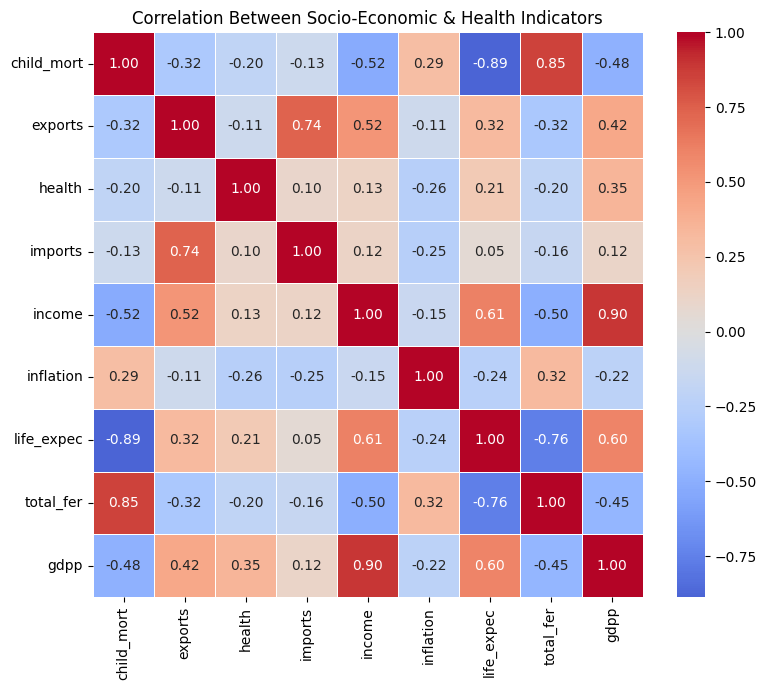

In [20]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Between Socio-Economic & Health Indicators")
plt.tight_layout()
plt.show()


## 6. Feature Scaling

The **country** column is used only to identify each country, so it is not included in the clustering process. It is kept only to help identify the clusters later.

The remaining nine numeric columns are scaled using **StandardScaler**. This step is important because clustering algorithms like **K-Means** and **DBSCAN** measure distances between data points. Without scaling, features with larger values, such as **income** and **gdpp**, would have a much bigger influence than features with smaller values, such as **total_fer**, even if they are not more important.


In [21]:
country_names = df["country"].astype(str).str.strip()
X = df[numeric_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled feature matrix shape: {X_scaled.shape}")
# print(f"Mean per feature (should be 0): {X_scaled.mean(axis=0)}")
print(f"Mean per feature (should be Appox 0): {X_scaled.mean(axis=0).round(2)}")
print(f"Std per feature (should be Appox 1): {X_scaled.std(axis=0).round(2)}")


Scaled feature matrix shape: (167, 9)
Mean per feature (should be Appox 0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std per feature (should be Appox 1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 7. Elbow Method -For Choosing K

We run the K-Means algorithm with the number of clusters (k) ranging from 2 to 10 and record the **inertia** (within-cluster sum of squares) for each value. The **elbow method** is then used to choose a suitable number of clusters. The best value of **k** is usually where the decrease in inertia starts to slow down, meaning that adding more clusters does not significantly improve the results.


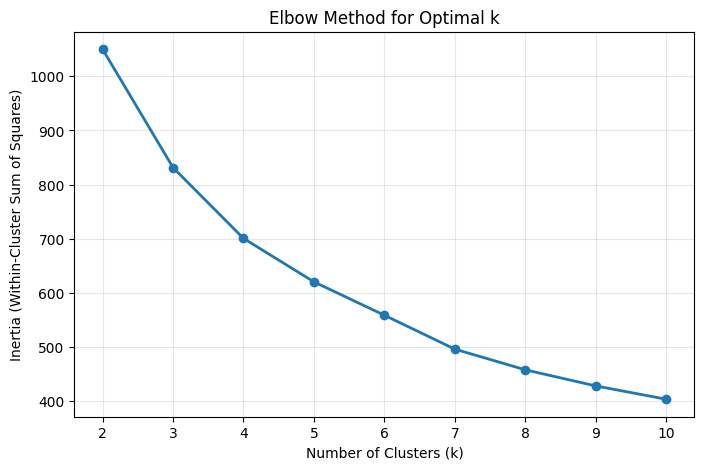

 k= 2: inertia=1050.2145582853307
 k= 3: inertia=831.424435208687
 k= 4: inertia=700.52053697222
 k= 5: inertia=620.163371288842
 k= 6: inertia=558.4696598590399
 k= 7: inertia=495.8079455215346
 k= 8: inertia=457.5861478912421
 k= 9: inertia=427.80367198134667
 k= 10: inertia=403.2296125136434


In [22]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    # init="k-means++" better way of choosing the cluster center
    # initally rather than picking randomly !!
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o", linewidth=2)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

for k, inertia in zip(k_range, inertias):
    print(f" k= {k}: inertia={inertia}")


## 8. K-Means Clustering (k = 3)
The elbow plot shows that the decrease in inertia becomes much smaller after **k = 3**, indicating that three clusters are a good choice.Therefore, we select **k = 3** as the final number of clusters for the K-Means model.


In [23]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"] = kmeans_labels
print(f"K-Means fit with k={best_k}")
print(df["kmeans_cluster"].value_counts().sort_index())


K-Means fit with k=3
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


## 9. Evaluating Cluster Quality Using Silhouette Score

The **silhouette score** measures how well the clusters are separated from each other  and how similar the data points are within the same cluster. Its value ranges from -1 to +1, where values closer to +1 indicate better clustering.


In [24]:
sil_score = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score (K-Means, k={best_k}): {sil_score:.4f}")


Silhouette Score (K-Means, k=3): 0.2833


## 10. Comparative Model-DBSCAN
DBSCAN groups data based on how closely the data points are packed together instead of using a fixed number of clusters. It also identifies points that do not belong to any dense group as outliers (label = -1).This helps us check whether the countries identified as at-risk actually form a clear cluster or if some of them are better treated as individual outliers.

In [25]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = dbscan_labels

# Find all unique labels
unique_labels = set(dbscan_labels)

# Remove -1 from the list because noise is not a real cluster
if -1 in unique_labels:
    unique_labels.remove(-1)

# Count how many actual clusters are !!
n_clusters_db = len(unique_labels)

# Count how many total points were labeled as noise (-1)
n_noise = list(dbscan_labels).count(-1)

print(f"dbscan found {n_clusters_db} clusters and flagged {n_noise} points as noise.")
print(df["dbscan_cluster"].value_counts().sort_index())

if n_clusters_db > 1:
    # Silhouette score on DBSCAN is only meaningful excluding noise points
    mask = dbscan_labels != -1
    if mask.sum() > 0 and len(set(dbscan_labels[mask])) > 1:
        db_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        print(f"DBSCAN silhouette score (noise excluded): {db_sil:.4f}")


dbscan found 1 clusters and flagged 30 points as noise.
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


## 11.  PCA (Principal Component Analysis) & Visualization

 the dataset has nine scaled features, it cannot be visualized directly in a 2D plot. PCA  reduces the data to the two most important components while preserving as much imp information as possible. This allows us to plot the data and visually check whether the K-Means clusters are clearly separated.


Explained variance: PC1=46.0%, PC2=17.2%, Total=63.1%


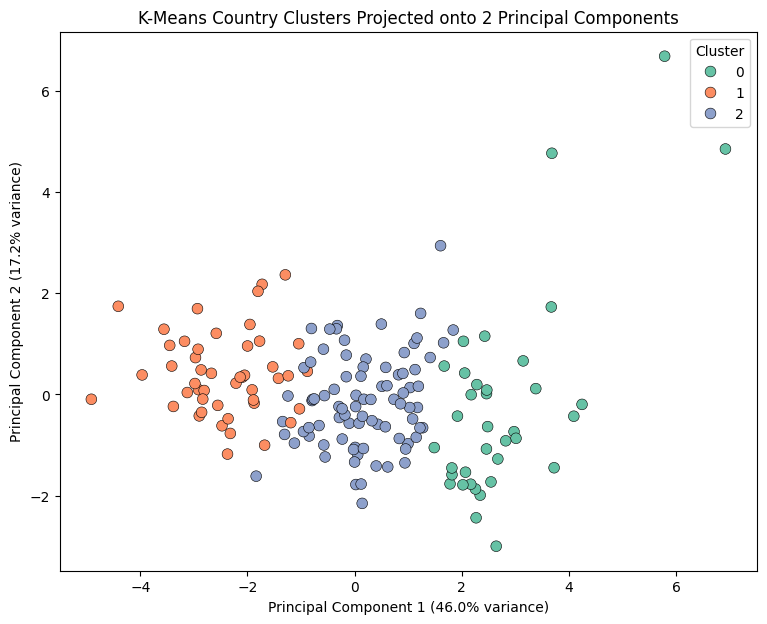

In [26]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_

print(f"Explained variance: PC1={ev[0]:.1%}, PC2={ev[1]:.1%}, Total={sum(ev):.1%}")

plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=df["kmeans_cluster"],
    palette="Set2", s=60, edgecolor="black", linewidth=0.4
)
plt.xlabel(f"Principal Component 1 ({ev[0]:.1%} variance)")
plt.ylabel(f"Principal Component 2 ({ev[1]:.1%} variance)")
plt.title("K-Means Country Clusters Projected onto 2 Principal Components")
plt.legend(title="Cluster")
plt.show()

## 12. Profiling the Clusters

The cluster labels (0, 1, and 2) do not have any meaning by ifself. To understand what each cluster represents, we examine the average values of the features within each cluster. This helps us identify the characteristics of the countries in each group.


In [27]:
cluster_profile = df.groupby("kmeans_cluster")[numeric_cols].mean().round(1)
cluster_profile["n_countries"] = df["kmeans_cluster"].value_counts().sort_index()
cluster_profile


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,n_countries
kmeans_cluster,,,,,,,,,,
0,5.0,58.7,8.8,51.5,45672.2,2.7,80.1,1.8,42494.4,36
1,93.0,29.2,6.4,42.3,3942.4,12.0,59.2,5.0,1922.4,47
2,21.9,40.2,6.2,47.5,12305.6,7.6,72.8,2.3,6486.5,84


In [28]:
# Identify which cluster is which, based on child mortality and gdpp
mortality_by_cluster = df.groupby("kmeans_cluster")["child_mort"].mean().sort_values(ascending=False)
gdpp_by_cluster = df.groupby("kmeans_cluster")["gdpp"].mean().sort_values(ascending=False)

high_need_cluster = mortality_by_cluster.index[0]
developed_cluster = gdpp_by_cluster.index[0]

print("Clusters With child mortality (highest first):")
print(mortality_by_cluster.round(1))
print("Clusters With GDP per capita (highest first):")
print(gdpp_by_cluster.round(1))

print(f"\nLikely 'high-need' cluster: {high_need_cluster}")
print(f"Likely 'developed' cluster: {developed_cluster}")

print("\nSample countries in the high-need cluster:")
print(country_names[df['kmeans_cluster'] == high_need_cluster].head(10).tolist())

print("\nSample countries in the developed cluster :")
print(country_names[df['kmeans_cluster'] == developed_cluster].head(10).tolist())


Clusters With child mortality (highest first):
kmeans_cluster
1    93.0
2    21.9
0     5.0
Name: child_mort, dtype: float64
Clusters With GDP per capita (highest first):
kmeans_cluster
0    42494.4
2     6486.5
1     1922.4
Name: gdpp, dtype: float64

Likely 'high-need' cluster: 1
Likely 'developed' cluster: 0

Sample countries in the high-need cluster:
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros']

Sample countries in the developed cluster :
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland']


## 13. K-Means vs. DBSCAN — Side-by-Side

In [29]:
comparison = pd.crosstab(df["kmeans_cluster"], df["dbscan_cluster"])
comparison.index.name = "K-Means Cluster"
comparison.columns.name = "DBSCAN Cluster (-1 = noise)"
comparison


DBSCAN Cluster (-1 = noise),-1,0
K-Means Cluster,,
0,9,27
1,16,31
2,5,79


## 14. Observations & Conclusion

**1. K-Means (k = 3) divides the countries into three main groups.**
The model groups the 167 countries into clusters of 84, 47, and 36 countries. These clusters broadly represent middle-income, at-risk or low-income, and high-income countries. The silhouette score of 0.28 shows that the clusters are reasonably well separated, although the separation is moderate rather than perfect. This is expected because countries usually develop gradually, so there are no clear boundaries between different levels of development.

**2. One cluster clearly represents countries with the greatest development challenges**.

This cluster contains 47 countries including Afghanistan, Angola, Benin, Burkina Faso, Chad, and the Central African Republic. On average, these countries have a child mortality rate of about 93 deaths per 1,000 live births and a GDP per capita of around $1,922. These values indicate that this group has the greatest need for improvements in healthcare, income, and overall development.

**3. Another cluster represents developed countries.**

This group contains 36 countries, including Australia, Austria, Canada, Denmark, and Finland. It has an average GDP per capita of about $42,494 and a child mortality rate of only 5 deaths per 1,000 live births. Compared with the high-need cluster, these countries have much higher income levels and much lower child mortality, showing a strong relationship between economic development and child health.

**4. The largest cluster represents countries in transition.**

The remaining 84 countries fall between the other two groups. They have an average child mortality rate of about 22 deaths per 1,000 live births and an average GDP per capita of around $6,487. These countries have made progress in development but have not yet reached the levels of high-income economies.

**5. PCA visualization supports the clustering results.**

The first two principal components explain 63.1% of the total variation in the data (46.0% + 17.2%). In the PCA plot, the three K-Means clusters appear mostly separate with only a small amount of overlap. This suggests that the clusters reflect real patterns in the data rather than being created artificially by the algorithm.

**6. DBSCAN provides a different perspective.**

Using eps = 1.5 and min_samples = 5, DBSCAN identified one large cluster containing 137 countries and labeled the remaining 30 countries as outliers (noise). These outliers include both some of the poorest, highest-mortality countries and some of the wealthiest, smallest economies. Unlike K-Means, which assigns every country to a cluster, DBSCAN highlights countries that do not fit well into any dense group.

**Conclusion :**

For identifying countries that may require greater development support, the 47-country high-need cluster from K-Means is the most useful result. At the same time, the 30 countries identified as outliers by DBSCAN should be examined individually, as they have characteristics that make them different from the main groups.